# 🟠 TP3 | Projeto de Bloco: Inteligência Artificial e Machine Learning

**Objetivo:** O projeto tem como objetivo proporcionar aos alunos experiência prática em técnicas avançadas de Machine Learning, focando em classificação binária e redução de dimensionalidade

Base de dados: [Fake.BR - Corpus](https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/refs/heads/master/preprocessed/pre-processed.csv)

## ⤵️ Imports

In [99]:
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import nltk

In [100]:
raw_data = pd.read_csv('https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/refs/heads/master/preprocessed/pre-processed.csv')

In [101]:
raw_data.head()

,index,label,preprocessed_news
0,0,fake,katia abreu diz vai colocar expulsao moldura n...
1,1,fake,ray peita bolsonaro conservador fake entrevist...
2,2,fake,reinaldo azevedo desmascarado policia federal ...
3,3,fake,relatorio assustador bndes mostra dinheiro pub...
4,4,fake,radialista americano fala sobre pt vendem ilus...


In [102]:
nltk.download('stopwords')
stopwords_pt = stopwords.words('portuguese')

raw_data['label'] = raw_data['label'].map({
  'fake': 0,
  'true': 1
})

y = raw_data['label']
X = (
    raw_data['preprocessed_news']
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(r'\d+', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(
    max_df = 0.95,
    min_df=0.02,
    max_features=600,
    stop_words=stopwords_pt
)

X_train_tfidf = tfidf.fit_transform(X_train)
feature_names = tfidf.get_feature_names_out()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## ⏳ Criação das features
📍 Aplicar Análise de Componentes Principais (PCA) para reduzir a dimensionalidade dos conjuntos de dados.

In [103]:
pca1 = PCA()
X_pca1 = pca1.fit(X_train_tfidf.toarray())

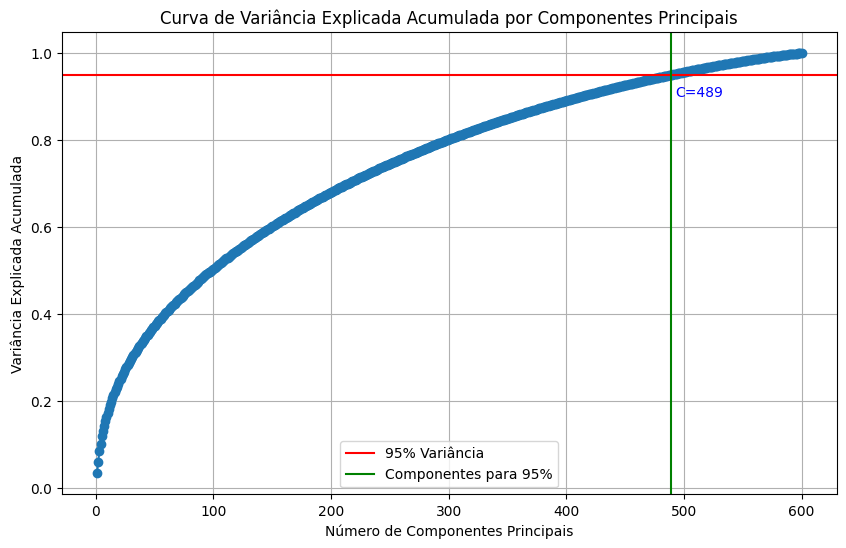

In [104]:
cumulative_variance_ratio = np.cumsum(X_pca1.explained_variance_ratio_)

plt.figure(figsize=(10, 6))

plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variância')
plt.axvline(x=np.argmax(cumulative_variance_ratio >= 0.95) + 1, color='g', linestyle='-', label='Componentes para 95%')

plt.annotate(
    f'C={np.argmax(cumulative_variance_ratio >= 0.95) + 1}',
    xy=(np.argmax(cumulative_variance_ratio >= 0.95) + 1, 0.95),
    xytext=(np.argmax(cumulative_variance_ratio >= 0.95) + 5, 0.9),
    color='blue'
)

plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Curva de Variância Explicada Acumulada por Componentes Principais')
plt.grid(True)

plt.legend()
plt.show()

#### 🗣️ Cometários

Aqui apliquei o TF-IDF e o PCA para entender quantos componentes seriam precisos para atingir 95% dos dados. Desta forma, conseguimos estimar quais valores testar no GridSearchCV, diminuindo o tempo execução.

De todo modo, ambas as etapas serão aplicadas no Pipeline constrído abaixo.

## 🤖 Modelo de ML
📍 Desenvolver e treinar modelos de árvores de decisão para tarefas de classificação.

## ☑️ Avaliação de Modelos
📍 Aplicar técnicas de validação cruzada para estimar a eficiência dos modelos desenvolvidos.

## 🔀 Busca Hiperparamétrica
📍 Utilizar GridSearch para otimizar os hiperparâmetros dos modelos.

## 🪾 Pruning de Árvores de Decisão
📍 Realizar o pruning (poda) em árvores de decisão para prevenir o overfitting e melhorar a generalização do modelo.

## 🤔 Avaliação de Classificadores Binários
📍 Utilizar figuras de mérito como Curva ROC, precisão, recall, f1-score, sensibilidade e especificidade para avaliar os modelos.

In [105]:
DecisionTreeClassifier?

In [106]:
# TF-IDF
tfidf = TfidfVectorizer(
    max_df = 0.95,
    min_df=0.02,
    max_features=600,
    stop_words=stopwords_pt
)

# PCA
pca_model = PCA()

# Decision Tree
dtc = DecisionTreeClassifier(
    class_weight='balanced'
)


# Pipeline
classifier = Pipeline([
    ('tf-idf', tfidf),
    ('pca', pca_model),
    ('classifier', dtc)
])

In [107]:
# Parâmetros à serem testados
param_grid = {
    'pca__n_components': [100, 200, 500],
    'classifier__max_depth': [5, 8, 10]
}

# Indicadores de avaliação
scoring = {
  'precision': 'precision',
  'recall': 'recall',
  'accuracy': 'accuracy',
  'roc_auc': 'roc_auc',
  'f1': 'f1',
  'especificidade': make_scorer(recall_score, pos_label=0)
}

# GridSearch com Cross Validate
model = GridSearchCV(
    estimator=classifier,
    param_grid=param_grid,
    scoring=scoring,
    cv=5,
    refit='precision',
    return_train_score=True,
    n_jobs=-1,
    error_score='raise'
).fit(X_train, y_train)

In [108]:
model.best_params_

{'classifier__max_depth': 5, 'pca__n_components': 500}

In [109]:
model.best_score_

np.float64(0.8767495140781492)

In [116]:
# TF-IDF
tfidf = TfidfVectorizer(
    max_df = 0.95,
    min_df=0.02,
    max_features=600,
    stop_words=stopwords_pt
)

# PCA
pca_model = PCA(model.best_params_['pca__n_components'])

# Decision Tree
dtc = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=model.best_params_['classifier__max_depth']
)


# Pipeline
classifier = Pipeline([
    ('tf-idf', tfidf),
    ('pca', pca_model),
    ('classifier', dtc)
]).fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [118]:
print('--- Figuras de mérito | Dados de teste ---')
print(f'Acurácia: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precisão: {precision_score(y_test, y_pred):.4f}')
print(f'Recall/Sensibilidade: {recall_score(y_test, y_pred):.4f}')
print(f'Especificidade: {recall_score(y_test, y_pred, pos_label=0):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred):.4f}')

--- Figuras de mérito | Dados de teste ---
Acurácia: 0.8604
Precisão: 0.8745
Recall/Sensibilidade: 0.8417
Especificidade: 0.8792
F1-Score: 0.8577


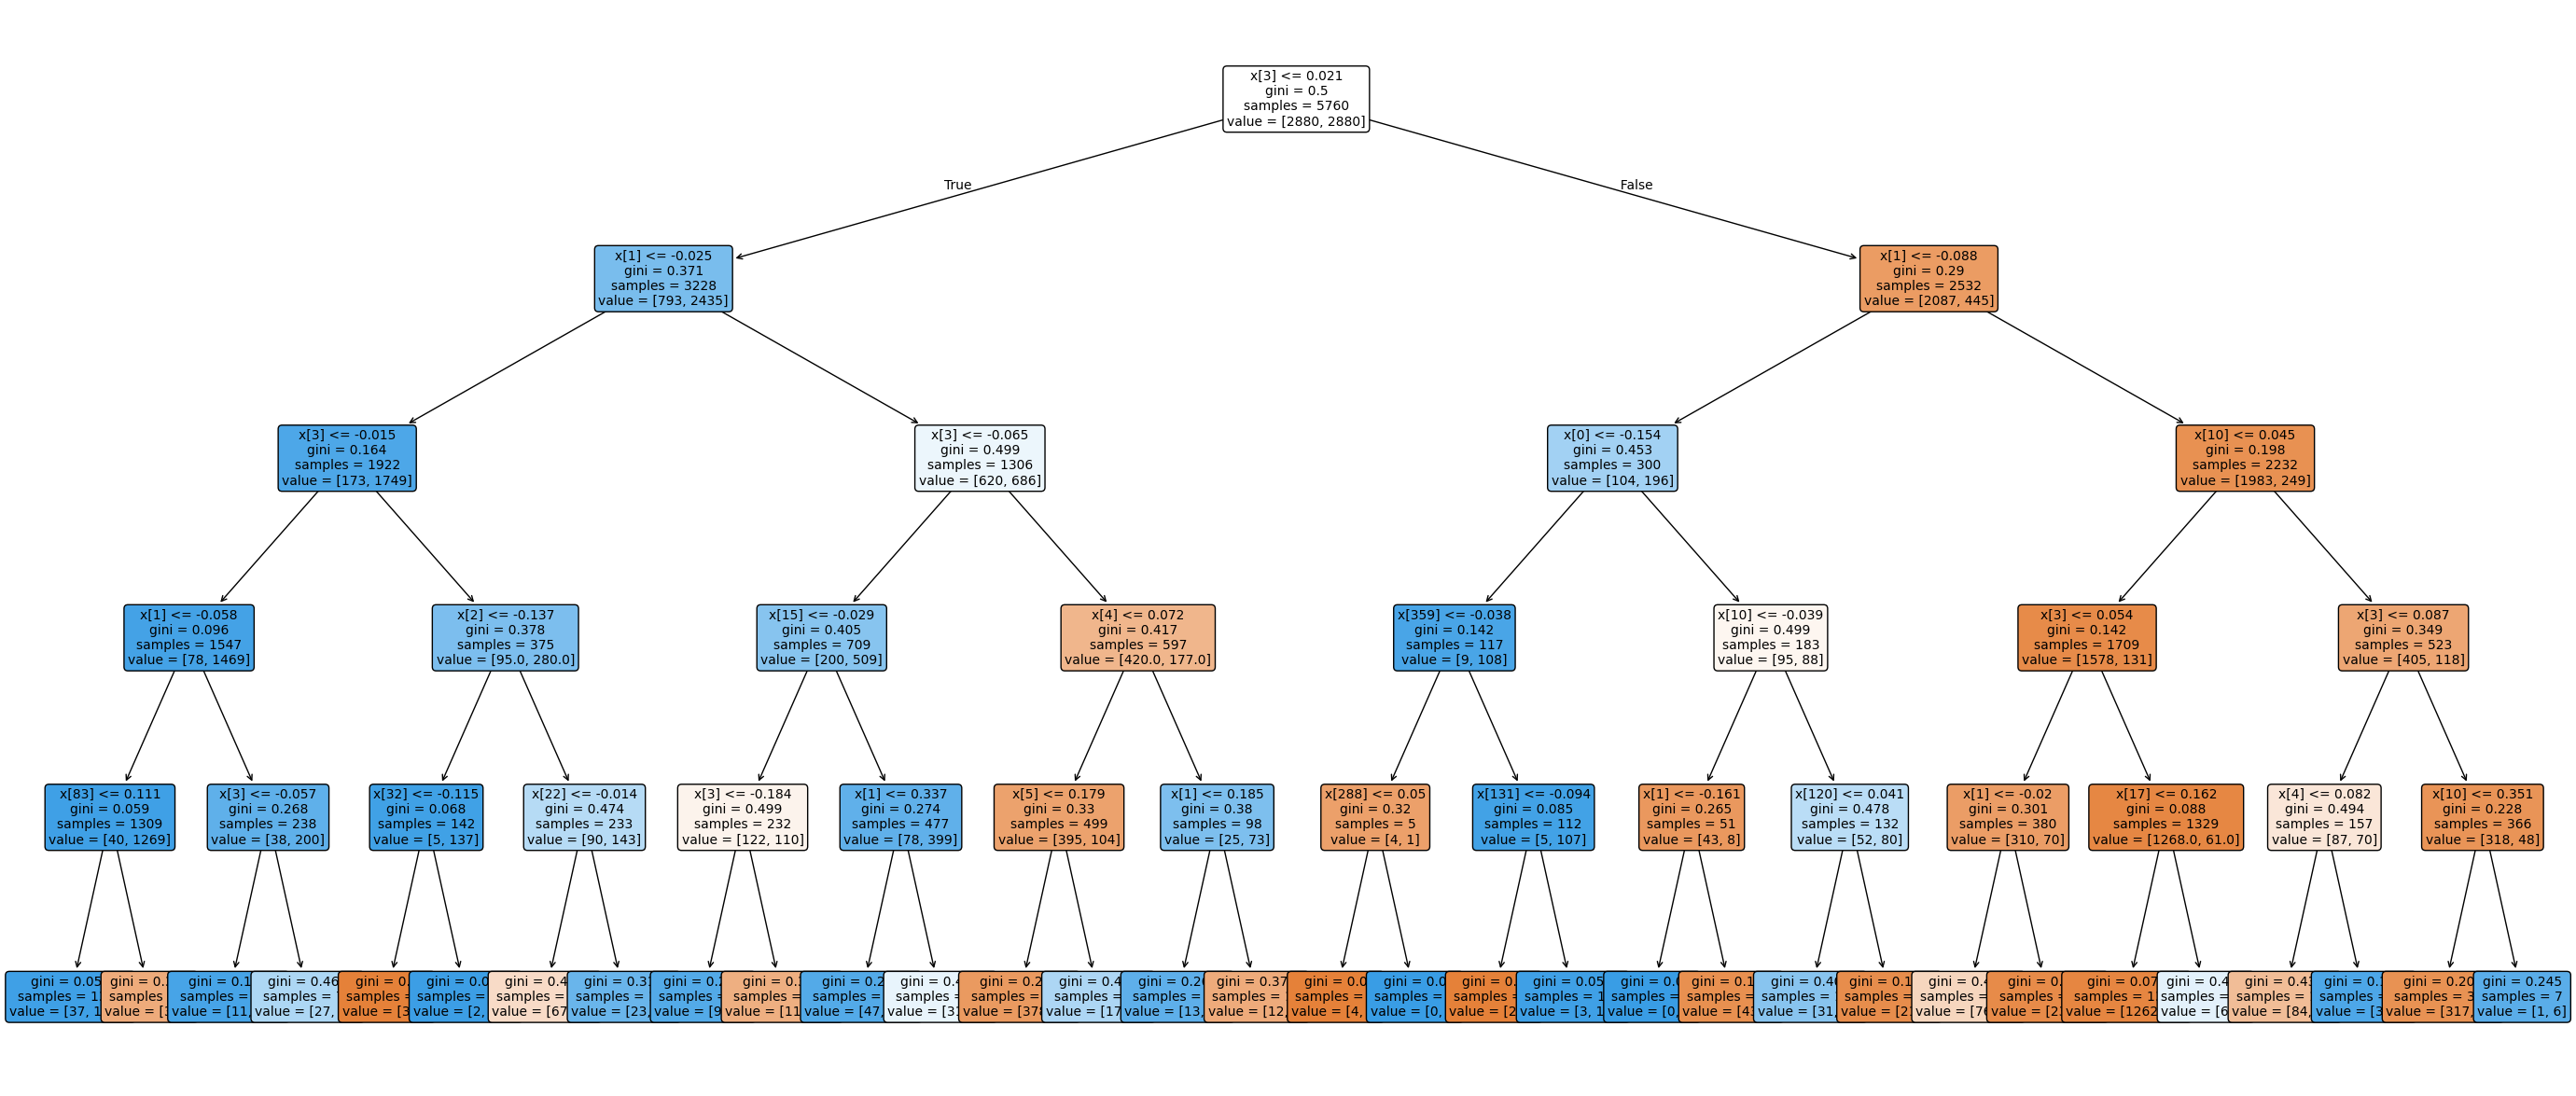

In [119]:
plt.figure(figsize=(35, 15))
plot_tree(dtc,
          filled=True,
          rounded=True,
          fontsize=10)

plt.show()

## 🗣️ Conclusão
📍 Baseado nos valores encontrados para as diferentes figuras de mérito, interprete os resultados e disserte sobre a eficiência do classificador criado.

#### 🗣️ Cometários
Baseado nos dados das figuras de mérito (precision, recall e f1-score bem próximos), vemos que o modelo está bem consistente, sem overfitting nem underfitting, muito menos algum viés em alguma classe (especificidade e sensibilidade altas).

Quando comparamos precision x recall, percebemos que o modelo é um pouco mais conservador, com a precisão maior. Isso significa que o modelo prefere errar por omissão do que classificar errado.